In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('fivethirtyeight')
%matplotlib inline
%config InlineBackend.figure_format = 'svg'  # 图片输出为矢量图，保证清晰度

In [2]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
data = pd.read_csv("./RNA_seq.csv")
dataT=np.array(data)
data=dataT.T
co=data[0]
data1=np.delete(data,0,axis=0)
data=data1
datadf= pd.DataFrame(data=data[0:,0:],columns=co)
datadf.head()
data=datadf
data= data.replace("NOTLC",value=0)
data= data.replace("LC",value=1)
X=data.drop(['Group'],axis=1)
y=data['Group']

In [4]:
df = data
df = df.dropna()
df = df.drop_duplicates()
from sklearn.neighbors import LocalOutlierFactor
lof = LocalOutlierFactor(n_neighbors=10, contamination=0.1)  # contamination 为异常值比例
lof_predictions = lof.fit_predict(df)
# 将预测结果添加到 DataFrame 中
df['LOF_Predictions'] = lof_predictions
# 筛选出离群值（预测结果为 -1 的点）
outliers = df[df['LOF_Predictions'] == -1]
print("离群值：")
print(outliers)
# 删除离群值所在的行
df_cleaned = df[df['LOF_Predictions'] == 1]  # 保留正常值
df_cleaned = df_cleaned.drop(columns=['LOF_Predictions'])  # 删除辅助列
print("删除离群值后的数据：")
print(df_cleaned)
df = df_cleaned
X=df.drop(['Group'],axis=1)
y=df['Group']

离群值：
      Group ENSG00000000003.15 ENSG00000000005.6 ENSG00000000419.13  \
8         1               7472                 1               4818   
26        1                791                 0                881   
31        1               1339                 0               3032   
37        1               1097                 1               1486   
56        1               2020                 1               1419   
...     ...                ...               ...                ...   
1027      1              10623                 3               4224   
1044      1               9468                 1               2420   
1055      1               4513                 0               4348   
1076      1               8401                 2               4145   
1081      1               2065                 0               5496   

     ENSG00000000457.14 ENSG00000000460.17 ENSG00000000938.13  \
8                   720                931                385   
26          

In [5]:
data

,Group,ENSG00000000003.15,ENSG00000000005.6,ENSG00000000419.13,ENSG00000000457.14,ENSG00000000460.17,ENSG00000000938.13,ENSG00000000971.16,ENSG00000001036.14,ENSG00000001084.13,...,ENSG00000288661.1,ENSG00000288662.1,ENSG00000288663.1,ENSG00000288665.1,ENSG00000288667.1,ENSG00000288669.1,ENSG00000288670.1,ENSG00000288671.1,ENSG00000288674.1,ENSG00000288675.1
0,1,1745,1,1923,1221,1018,2175,1943,1830,1653,...,0,1,88,0,0,0,262,0,12,56
1,1,3715,0,2468,249,395,150,500,2736,8506,...,0,0,3,0,0,0,55,0,1,2
2,1,1578,0,1194,693,664,1205,5244,1215,19392,...,0,0,11,0,0,2,260,0,12,16
3,1,7338,0,1872,596,1047,1656,6848,8263,9263,...,0,0,36,0,0,0,338,0,0,5
4,1,5495,5,4393,1334,954,737,6599,2430,33698,...,0,0,15,0,0,0,234,0,2,11
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1093,1,2078,5,1004,368,117,763,4473,1755,852,...,0,0,5,0,0,0,61,0,5,13
1094,1,1441,4,1877,882,424,278,2053,1894,5712,...,0,0,32,0,0,0,279,0,2,21
1095,1,1671,1,1100,649,226,5589,4520,2468,1541,...,0,0,26,0,0,0,203,0,7,23
1096,1,7829,0,2394,1007,1294,1175,2077,3673,2219,...,0,0,92,0,1,0,239,0,1,25


In [28]:
f1=['ENSG00000003147.19','ENSG00000004455.17','ENSG00000006327.14','ENSG00000018510.17','ENSG00000067064.11','ENSG00000154813.10','ENSG00000204305.14','ENSG00000234425.1','ENSG00000262772.2','ENSG00000272477.1']
f2=['ENSG00000106089.12', 'ENSG00000204305.14', 'ENSG00000223982.3','ENSG00000229693.2']
f3=['ENSG00000106089.12','ENSG00000138346.15','ENSG00000204305.14']
f4=['ENSG00000000005.6', 'ENSG00000002933.9','ENSG00000019144.19', 'ENSG00000070366.14','ENSG00000091262.16','ENSG00000106089.12','ENSG00000204305.14','ENSG00000233117.4']
f5=['ENSG00000011052.21','ENSG00000052841.15','ENSG00000062194.16','ENSG00000068001.14','ENSG00000102871.16','ENSG00000124532.15', 'ENSG00000204305.14', 'ENSG00000227066.2']

In [29]:
feature=list(set(f1+f2+f3+f4+f5))
feature

['ENSG00000223982.3',
 'ENSG00000006327.14',
 'ENSG00000062194.16',
 'ENSG00000003147.19',
 'ENSG00000234425.1',
 'ENSG00000000005.6',
 'ENSG00000018510.17',
 'ENSG00000004455.17',
 'ENSG00000233117.4',
 'ENSG00000091262.16',
 'ENSG00000272477.1',
 'ENSG00000262772.2',
 'ENSG00000124532.15',
 'ENSG00000067064.11',
 'ENSG00000138346.15',
 'ENSG00000052841.15',
 'ENSG00000106089.12',
 'ENSG00000204305.14',
 'ENSG00000154813.10',
 'ENSG00000102871.16',
 'ENSG00000229693.2',
 'ENSG00000068001.14',
 'ENSG00000011052.21',
 'ENSG00000002933.9',
 'ENSG00000019144.19',
 'ENSG00000227066.2',
 'ENSG00000070366.14']

In [5]:
df=data

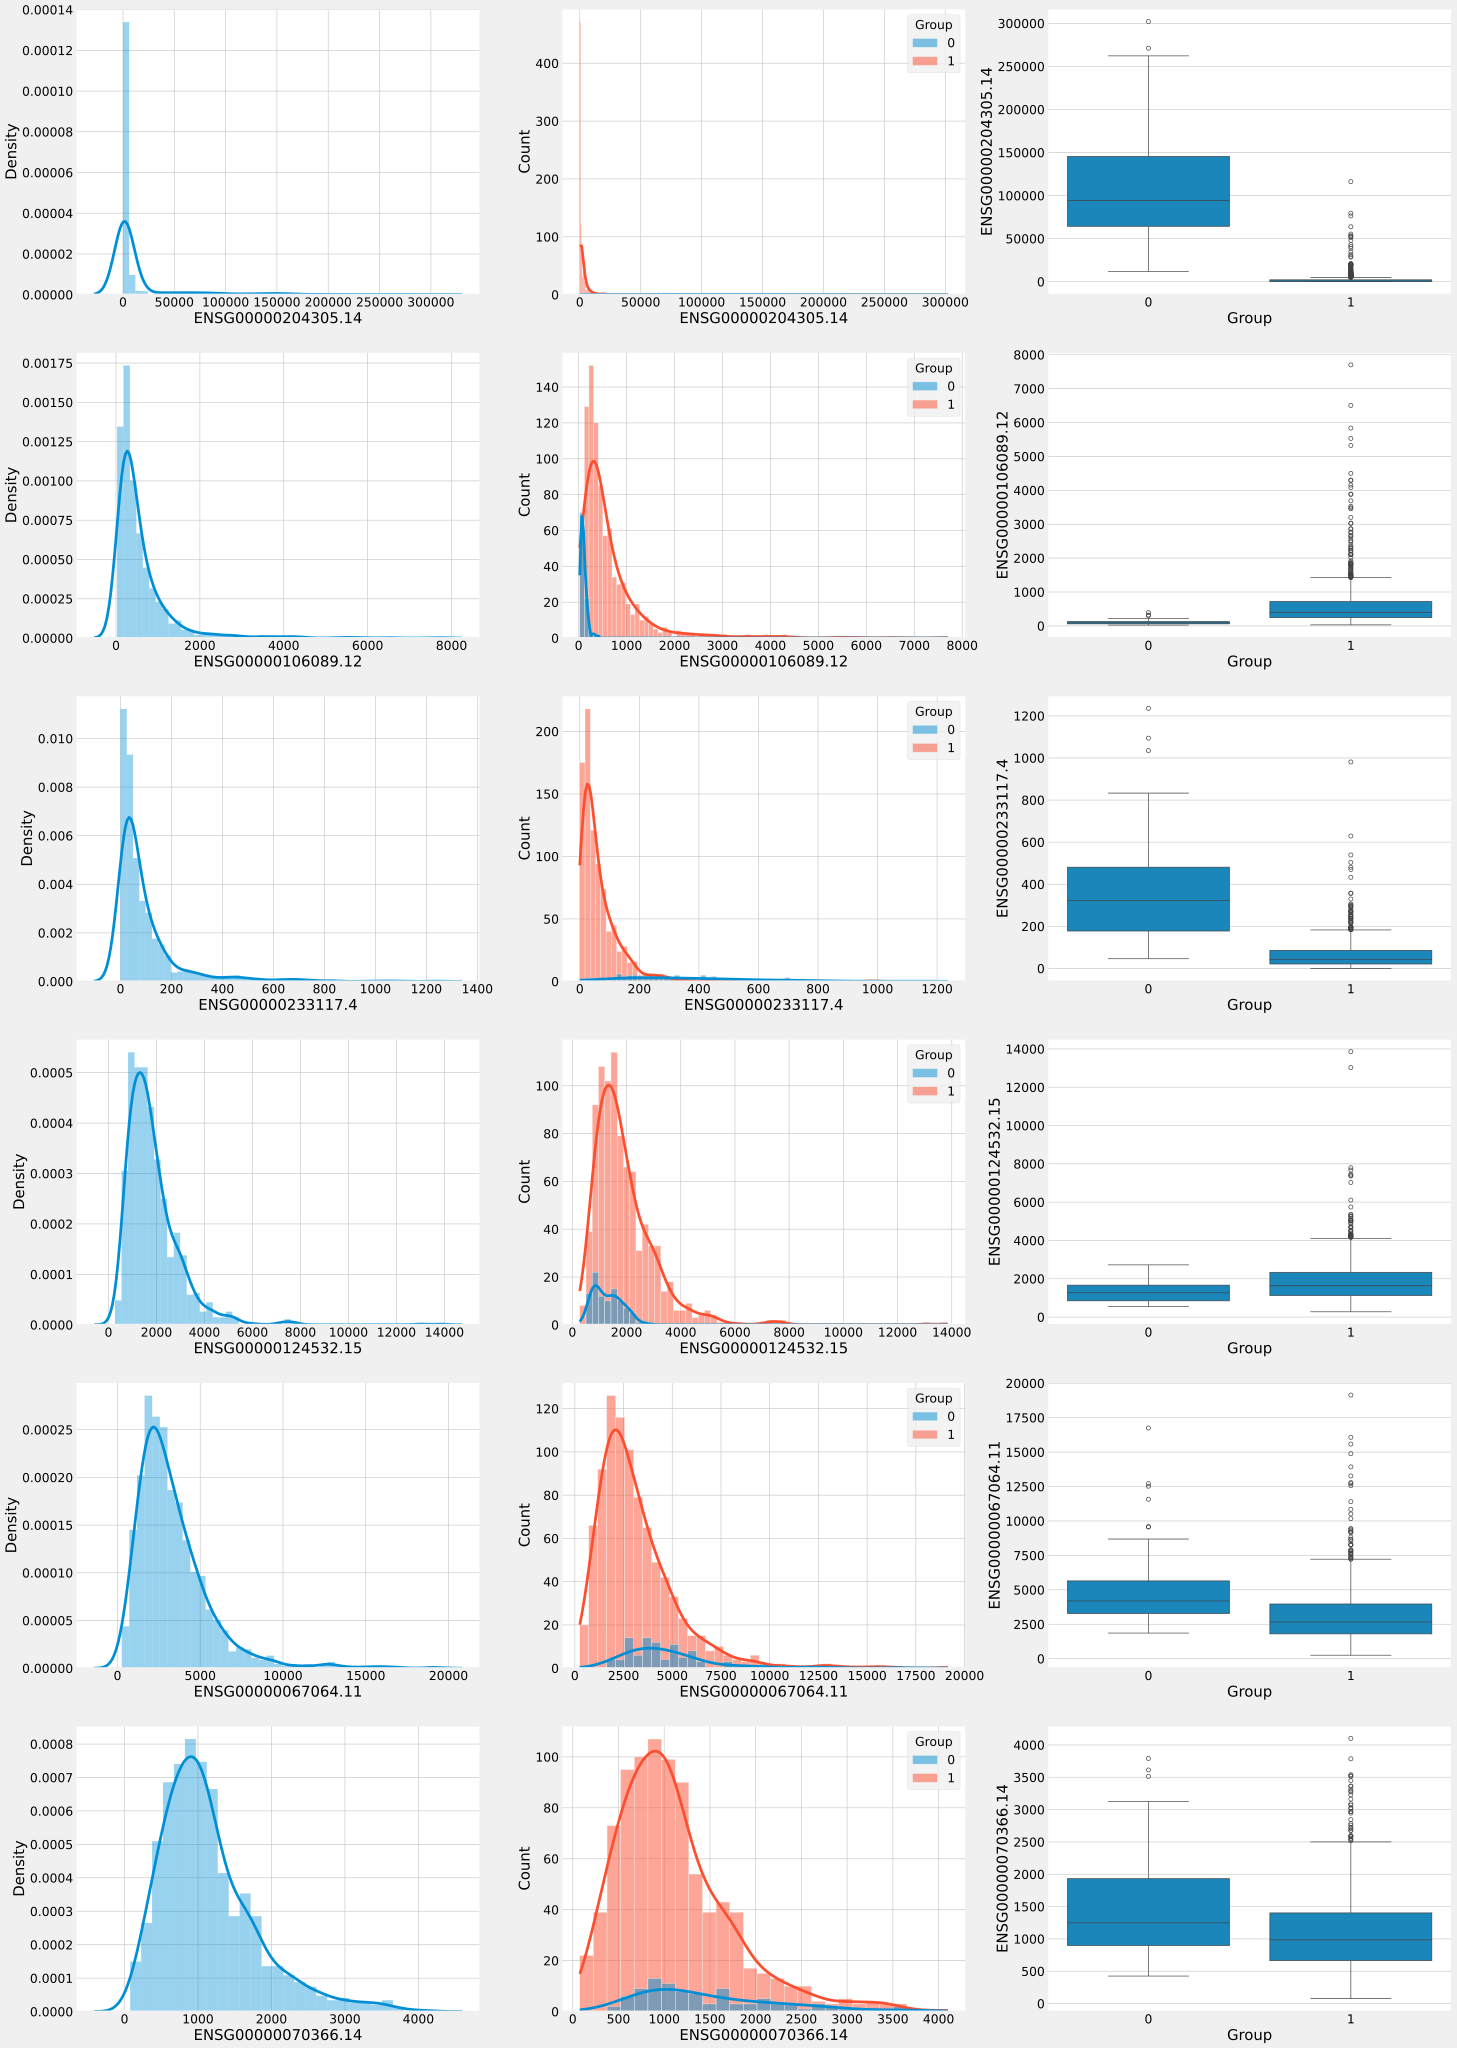

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# 设置字体大小
plt.rcParams.update({'font.size': 18})  # 可以根据需要调整字体大小

fig, ax = plt.subplots(6, 3, figsize=(32, 50))
# 遍历每个子图，设置背景颜色为白色
for a in ax.flat:
    a.set_facecolor('white')

sns.distplot(df['ENSG00000204305.14'], ax=ax[0][0])
sns.histplot(data=df, x='ENSG00000204305.14', ax=ax[0][1], hue='Group', kde=True)
sns.boxplot(x=df['Group'], y=df['ENSG00000204305.14'], ax=ax[0][2])

sns.distplot(df['ENSG00000106089.12'], ax=ax[1][0])
sns.histplot(data=df, x='ENSG00000106089.12', ax=ax[1][1], hue='Group', kde=True)
sns.boxplot(x=df['Group'], y=df['ENSG00000106089.12'], ax=ax[1][2])

sns.distplot(df['ENSG00000233117.4'], ax=ax[2][0])
sns.histplot(data=df, x='ENSG00000233117.4', ax=ax[2][1], hue='Group', kde=True)
sns.boxplot(x=df['Group'], y=df['ENSG00000233117.4'], ax=ax[2][2])

sns.distplot(df['ENSG00000124532.15'], ax=ax[3][0])
sns.histplot(data=df, x='ENSG00000124532.15', ax=ax[3][1], hue='Group', kde=True)
sns.boxplot(x=df['Group'], y=df['ENSG00000124532.15'], ax=ax[3][2])

sns.distplot(df['ENSG00000067064.11'], ax=ax[4][0])
sns.histplot(data=df, x='ENSG00000067064.11', ax=ax[4][1], hue='Group', kde=True)
sns.boxplot(x=df['Group'], y=df['ENSG00000067064.11'], ax=ax[4][2])

sns.distplot(df['ENSG00000070366.14'], ax=ax[5][0])
sns.histplot(data=df, x='ENSG00000070366.14', ax=ax[5][1], hue='Group', kde=True)
sns.boxplot(x=df['Group'], y=df['ENSG00000070366.14'], ax=ax[5][2])

plt.savefig('./Sample based explanation-2.jpg', dpi=500, bbox_inches='tight', facecolor='white')
plt.show()

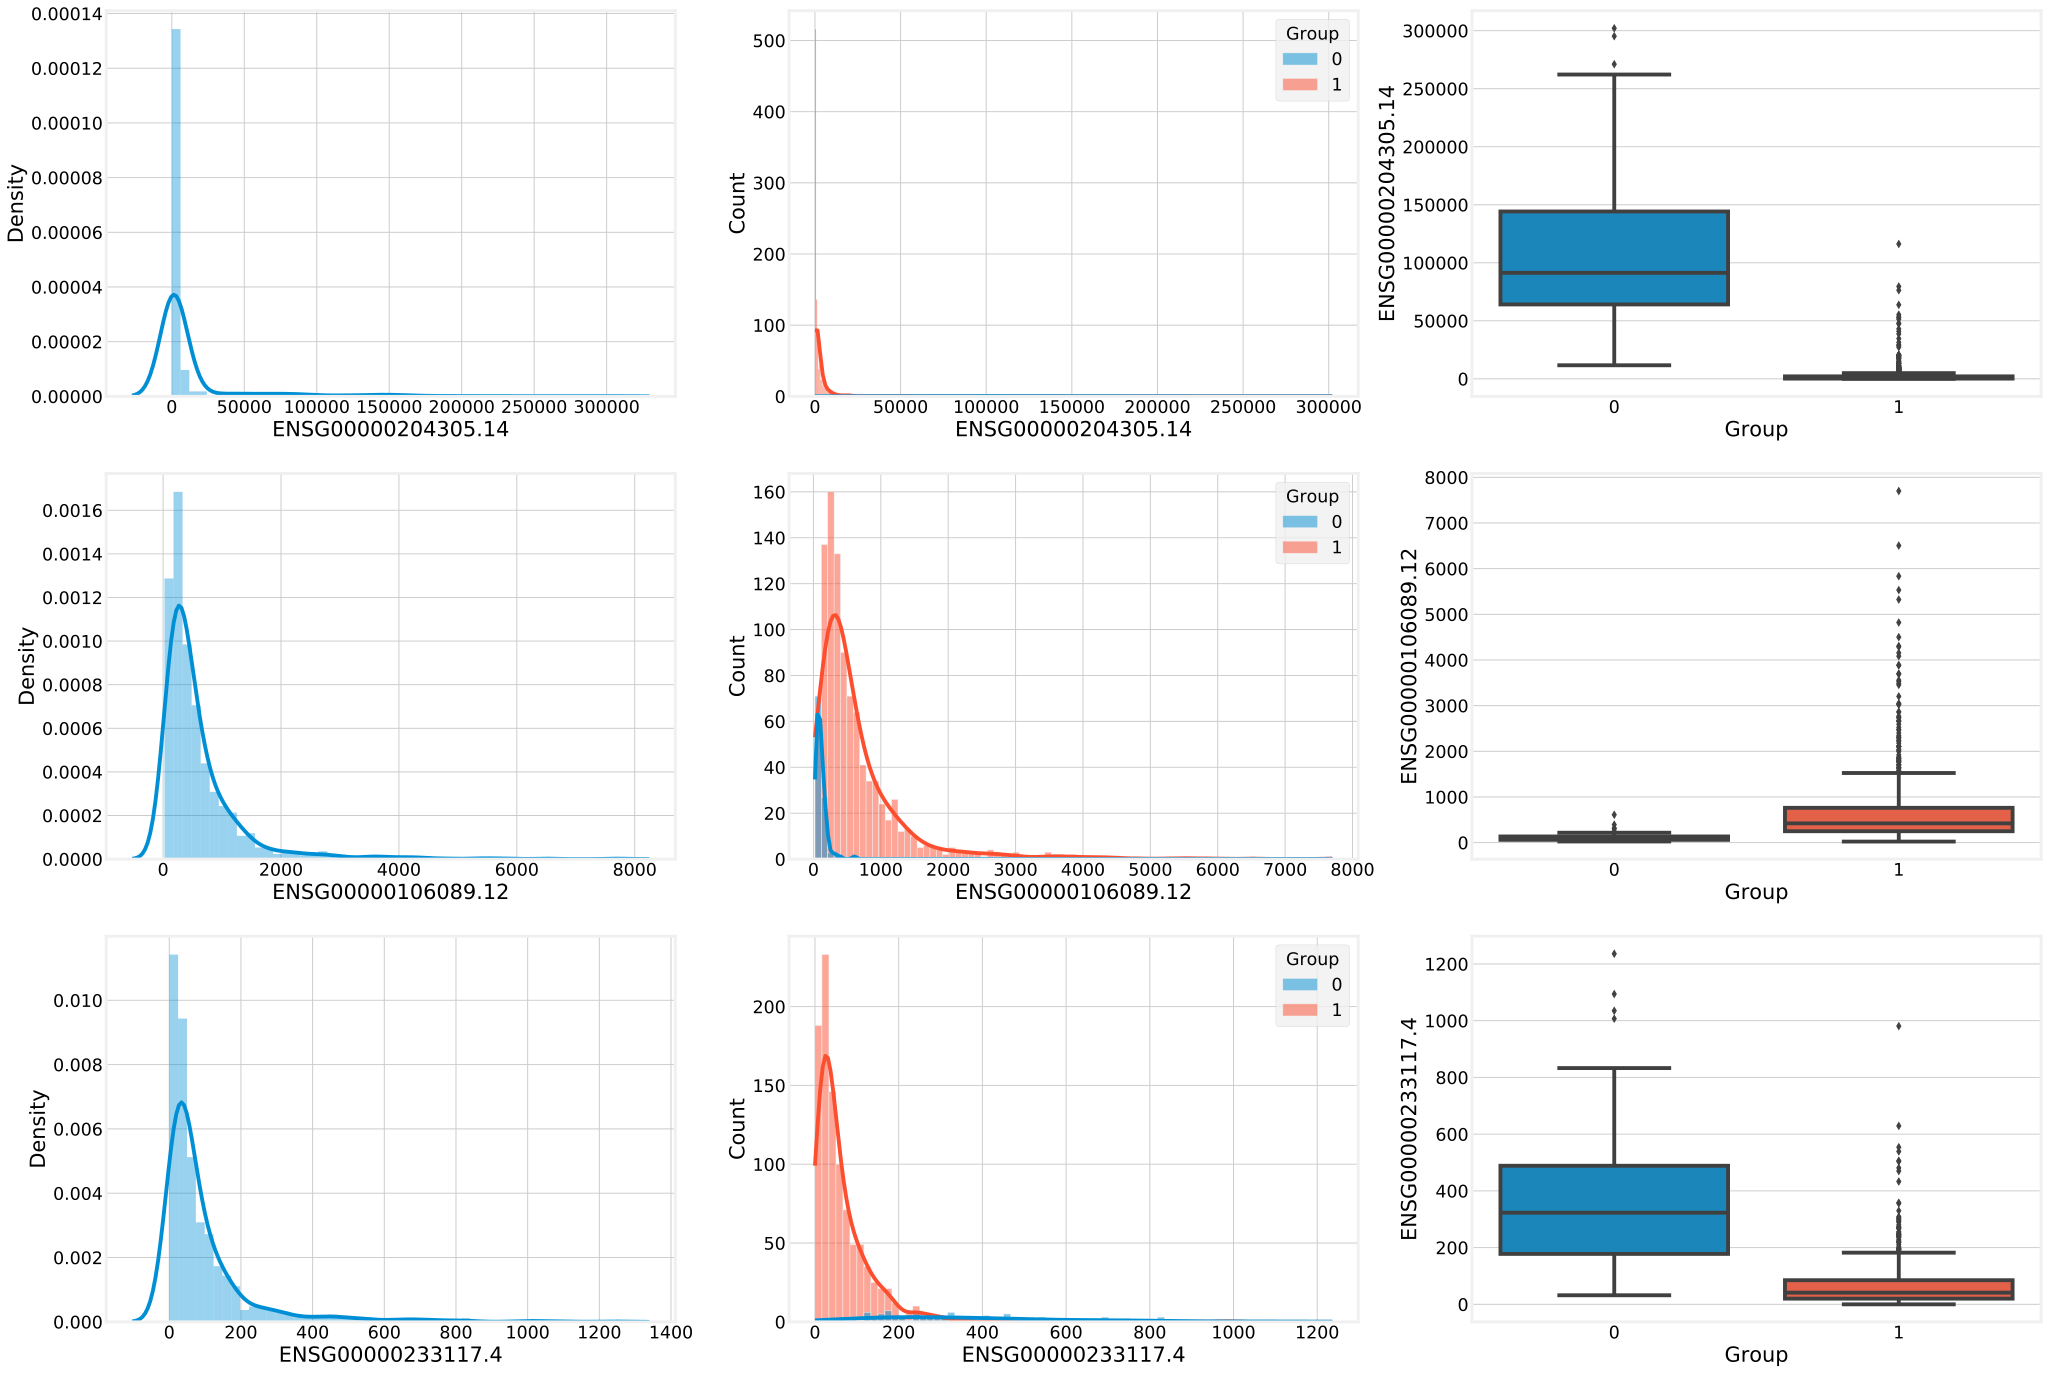

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# 设置字体大小
plt.rcParams.update({'font.size': 18})  # 可以根据需要调整字体大小

fig, ax = plt.subplots(3, 3, figsize=(32, 25))
# 遍历每个子图，设置背景颜色为白色
for a in ax.flat:
    a.set_facecolor('white')

sns.distplot(df['ENSG00000204305.14'], ax=ax[0][0])
sns.histplot(data=df, x='ENSG00000204305.14', ax=ax[0][1], hue='Group', kde=True)
sns.boxplot(x=df['Group'], y=df['ENSG00000204305.14'], ax=ax[0][2])

sns.distplot(df['ENSG00000106089.12'], ax=ax[1][0])
sns.histplot(data=df, x='ENSG00000106089.12', ax=ax[1][1], hue='Group', kde=True)
sns.boxplot(x=df['Group'], y=df['ENSG00000106089.12'], ax=ax[1][2])

sns.distplot(df['ENSG00000233117.4'], ax=ax[2][0])
sns.histplot(data=df, x='ENSG00000233117.4', ax=ax[2][1], hue='Group', kde=True)
sns.boxplot(x=df['Group'], y=df['ENSG00000233117.4'], ax=ax[2][2])

plt.savefig('./Sample based explanation-1.jpg', dpi=500, bbox_inches='tight', facecolor='white')
plt.show()

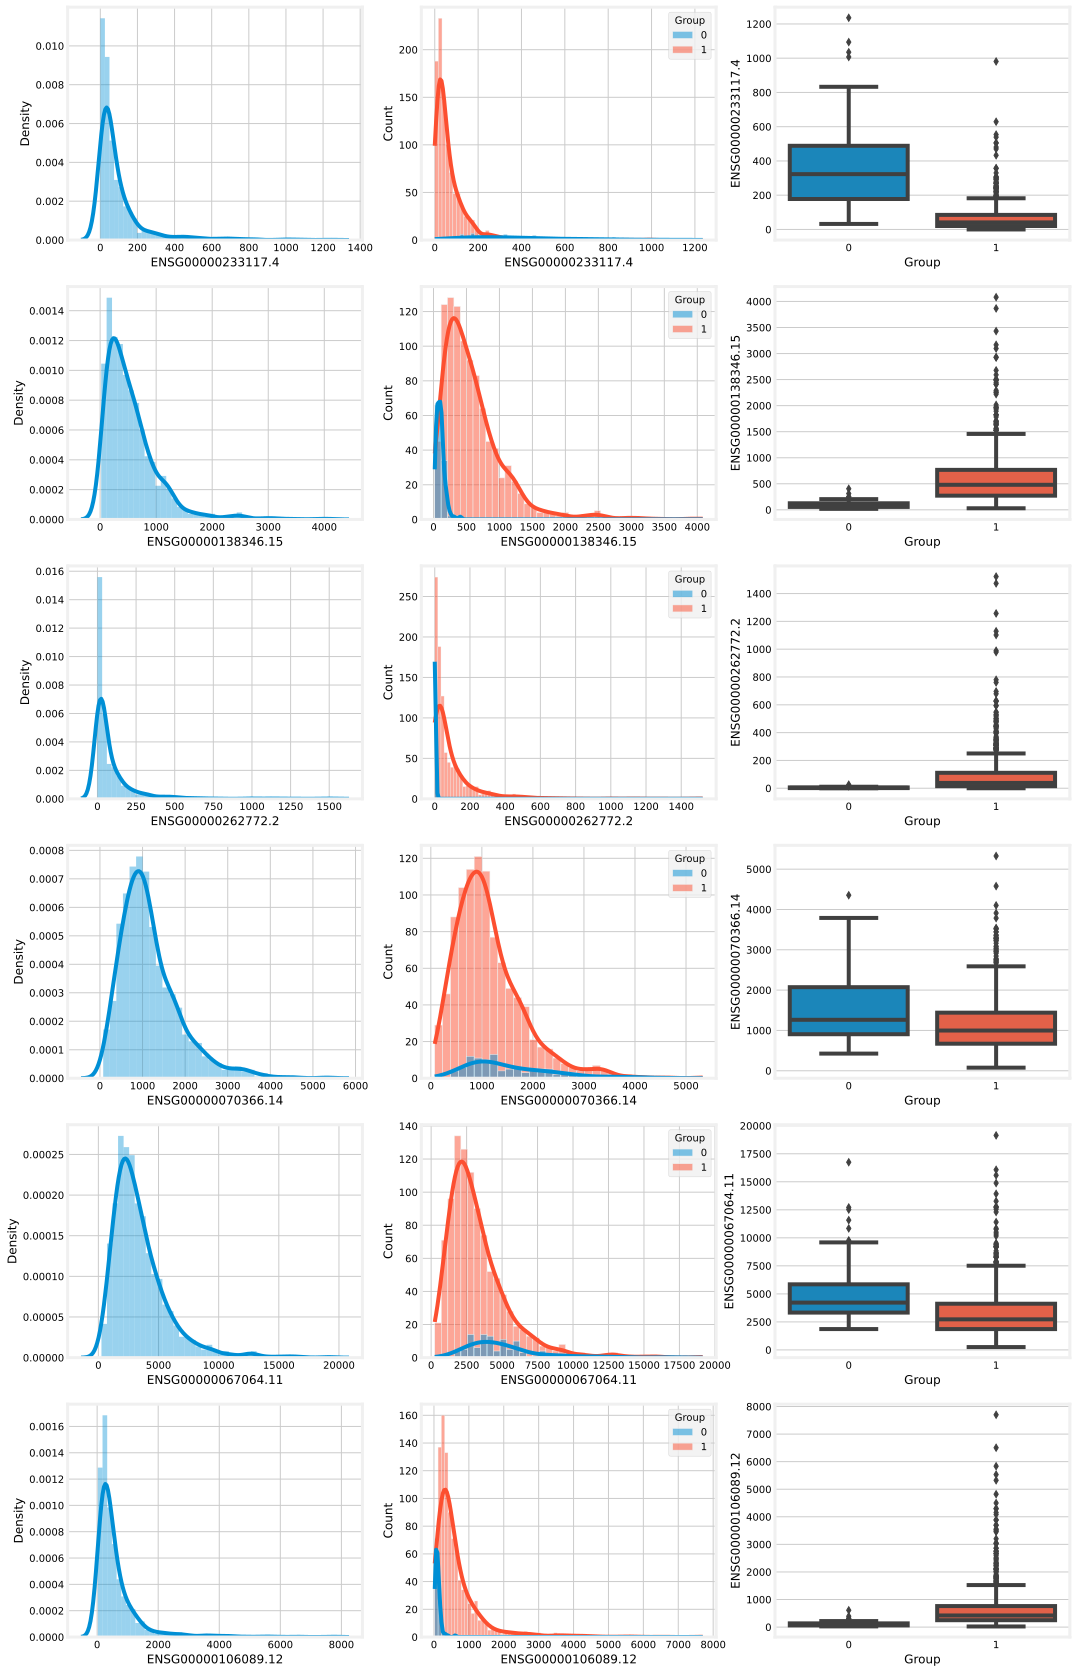

In [27]:
fig,ax = plt.subplots(6,3,figsize=(16,30))
# 遍历每个子图，设置背景颜色为白色
for a in ax.flat:
    a.set_facecolor('white')
sns.distplot(df['ENSG00000233117.4'],ax=ax[0][0])
sns.histplot(data =df,x='ENSG00000233117.4',ax=ax[0][1],hue='Group',kde=True)
sns.boxplot(x=df['Group'],y=df['ENSG00000233117.4'],ax=ax[0][2])
sns.distplot(df['ENSG00000138346.15'],ax=ax[1][0])
sns.histplot(data =df,x='ENSG00000138346.15',ax=ax[1][1],hue='Group',kde=True)
sns.boxplot(x=df['Group'],y=df['ENSG00000138346.15'],ax=ax[1][2])
sns.distplot(df['ENSG00000262772.2'],ax=ax[2][0])
sns.histplot(data =df,x='ENSG00000262772.2',ax=ax[2][1],hue='Group',kde=True)
sns.boxplot(x=df['Group'],y=df['ENSG00000262772.2'],ax=ax[2][2])
sns.distplot(df['ENSG00000070366.14'],ax=ax[3][0])
sns.histplot(data =df,x='ENSG00000070366.14',ax=ax[3][1],hue='Group',kde=True)
sns.boxplot(x=df['Group'],y=df['ENSG00000070366.14'],ax=ax[3][2])
sns.distplot(df['ENSG00000067064.11'],ax=ax[4][0])
sns.histplot(data =df,x='ENSG00000067064.11',ax=ax[4][1],hue='Group',kde=True)
sns.boxplot(x=df['Group'],y=df['ENSG00000067064.11'],ax=ax[4][2])
sns.distplot(df['ENSG00000106089.12'],ax=ax[5][0])
sns.histplot(data =df,x='ENSG00000106089.12',ax=ax[5][1],hue='Group',kde=True)
sns.boxplot(x=df['Group'],y=df['ENSG00000106089.12'],ax=ax[5][2])
plt.savefig('E:/lung_cancer_prediction/images/TCGA_RNAseq/Sample based explanation.jpg', dpi=500, bbox_inches='tight',facecolor='white')
plt.show()